In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("DATA\Infiltrasjonstester.csv", sep=";")

# Bytt komma til punktum og konverter til tall
for col in df.columns[1:]:
    df[col] = df[col].str.replace(",", ".").astype(float)

df.head()

,Tid i minutter,Rør 1 Københavngata,Rør 2 Københavngata,Rør 3 Københavngata,Rør 1 Deichmans gate,Rør 2 Deichmans gate,Rør 3 Deichmans gate,Rør 1 Maridalsveien,Rør 2 Maridalsveien
0,0,1.5,1.0,1.5,0.0,0.00,0.00,0.0,0.0
1,1,7.0,3.8,6.0,2.5,0.22,0.04,3.7,2.4
2,2,9.5,6.1,10.0,4.0,0.44,0.08,5.7,4.6
3,3,11.0,8.1,13.5,5.7,0.66,0.12,7.5,6.1
4,4,13.0,10.2,16.5,7.0,0.88,0.16,9.0,7.5


In [8]:
import matplotlib.pyplot as plt

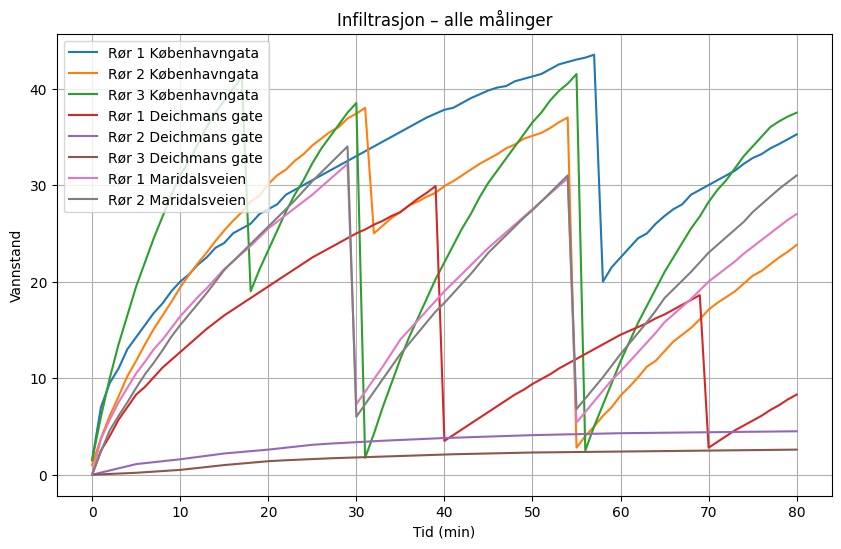

In [9]:
plt.figure(figsize=(10,6))

for col in df.columns[1:]:
    plt.plot(df["Tid i minutter"], df[col], label=col)

plt.xlabel("Tid (min)")
plt.ylabel("Vannstand")
plt.title("Infiltrasjon – alle målinger")
plt.legend()
plt.grid()
plt.show()

In [ ]:
df_hastighet = df.copy()

for col in df.columns[1:]:
    diff = df[col].diff()
    
    # Sett negative verdier til NaN (fjerner reset), for å unngå negative tall.
    diff[diff < 0] = None
    
    df_hastighet[col] = diff

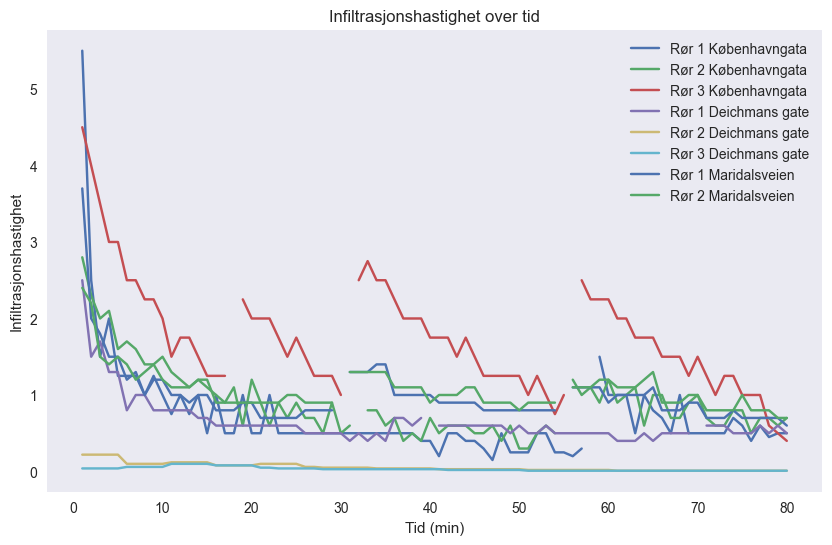

In [36]:
plt.figure(figsize=(10,6))

for col in df_hastighet.columns[1:]:
    plt.plot(df_hastighet["Tid i minutter"], df_hastighet[col], label=col)

plt.xlabel("Tid (min)")
plt.ylabel("Infiltrasjonshastighet")
plt.title("Infiltrasjonshastighet over tid")

plt.legend()
plt.grid()
plt.show()

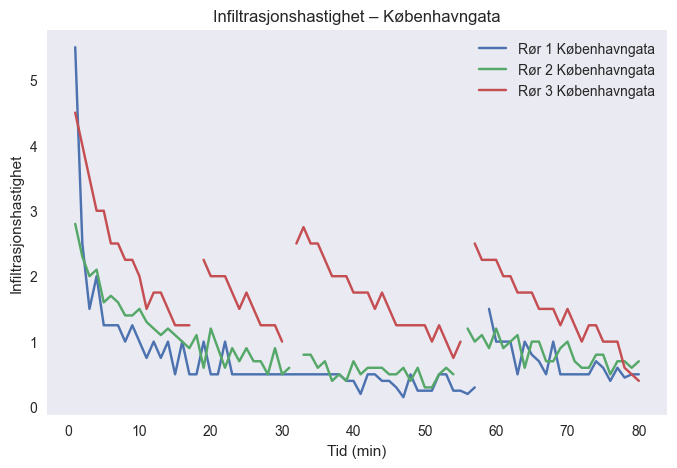

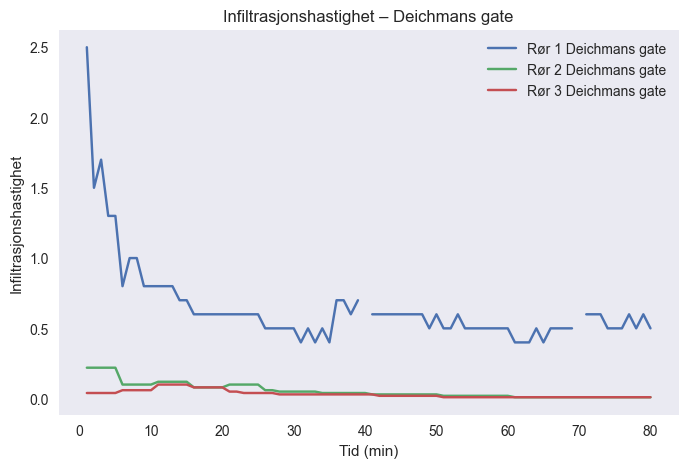

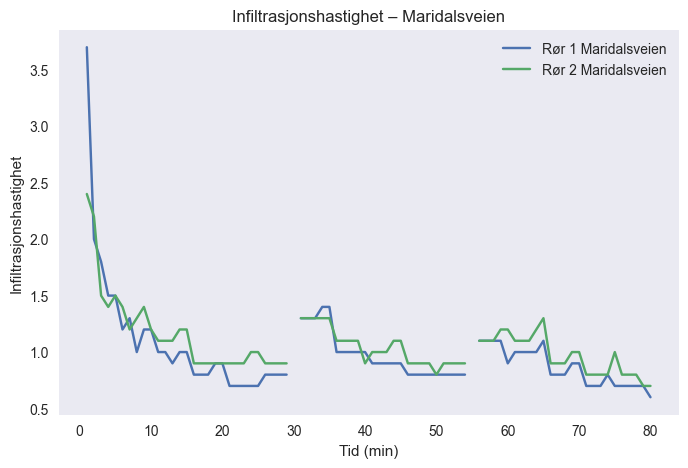

In [40]:
locations = ["Københavngata", "Deichmans gate", "Maridalsveien"]

for loc in locations:
    plt.figure(figsize=(8,5))
    
    cols = [col for col in df_hastighet.columns if loc in col]
    
    for col in cols:
        plt.plot(df_hastighet["Tid i minutter"], df_hastighet[col], label=col)
    
    plt.title(f"Infiltrasjonshastighet – {loc}")
    plt.xlabel("Tid (min)")
    plt.ylabel("Infiltrasjonshastighet")
    plt.legend()
    plt.grid()
    plt.show()

In [50]:
def finn_stabil_hastighet(series):
    # Fjern manglende verdier (NaN) fra dataserien
    s = series.dropna()
    
    # Gå bakover i serien, start nær slutten
    # Vi stopper på index 1 fordi vi ser på grupper av 3 verdier
    for i in range(len(s) - 3, 0, -1):
        
        # Hent ut 3 påfølgende verdier (et lite "vindu")
        subset = s.iloc[i:i+3]
        
        # Sjekk om verdiene er stabile:
        # forskjellen mellom maks og min må være mindre enn
        # 20 % av gjennomsnittet
        if subset.max() - subset.min() < 0.2 * subset.mean():
            
            # Hvis stabilt område er funnet:
            # returner gjennomsnittet som stabil hastighet
            return subset.mean()
    
    # Hvis vi ikke fant noe stabilt område:
    # bruk gjennomsnittet av de siste 5 verdiene som fallback
    return s.tail(5).mean()

In [51]:
# Finkornig jord (leire): Kₛₐₜ = 0,6 × stabil hastighet
# Grovkornig jord (sand/grus):Kₛₐₜ = 0,8 × stabil hastighet

ksat = {}

for col in df_hastighet.columns[1:]:
    stabil = finn_stabil_hastighet(df_hastighet[col])
    
    # Velg faktor
    if "Københavngata" in col:
        faktor = 0.8 # 50 % mellomsand og 50% siltig mellomsand. 
    elif "Maridalsveien" in col:
        faktor = 0.8 # Pukk 8-12mm med stauder.
    elif "Deichmans gate" in col:
        faktor = 0.8  # 4 % leire, 19 % silt og 77 % sand.
    
    ksat[col] = stabil * faktor

import pandas as pd
ksat_df = pd.DataFrame.from_dict(ksat, orient="index", columns=["Ksat"])
ksat_df

,Ksat
Rør 1 Københavngata,0.386667
Rør 2 Københavngata,0.533333
Rør 3 Københavngata,0.800000
Rør 1 Deichmans gate,0.426667
Rør 2 Deichmans gate,0.008000
Rør 3 Deichmans gate,0.008000
Rør 1 Maridalsveien,0.533333
Rør 2 Maridalsveien,0.586667
